In [16]:
import pandas as pd
data = pd.read_csv('../data/raw/dados_fundo_do_amanha_evcomx.csv', delimiter=';')
display(data.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,...,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,...,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
1,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,...,15.0,2557.0,46.0,1503.0,0.85,0.86,1652,1672,1543.0,1555.0
2,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,...,15.0,2557.0,46.0,1503.0,0.85,0.86,1650,1670,1543.0,1555.0
3,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,...,15.0,2557.0,46.0,1503.0,0.85,0.86,1655,1672,1543.0,1555.0
4,7691,180.0,EFDB105A,1F3F501C,0.02,0.18,0.20,0.01,0.01,2.0,...,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0


In [17]:
data = data.drop_duplicates(subset=['corrida'], keep='first')
display(data.head())

,corrida,secao,acoatual,qualidade,al_min,c_min,c_max,n_min,s_min,sequencia,...,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,velocidadeobjetivada,velocidadereal,sugestaomodelolegado,temperaturasaidafp,temperaturaobjetivada,temperaturamediareal
0,7691,180.0,336236CB,1F3F501C,0.02,0.16,0.18,0.01,0.01,2.0,...,15.0,2557.0,46.0,1503.0,0.85,0.86,1648,1670,1543.0,1555.0
6,7690,180.0,D7B079C7,1F3F501C,0.02,0.14,0.16,0.01,0.01,1.0,...,4.0,959.0,51.0,1503.0,0.85,0.85,1674,1678,1543.0,1547.0
28,7689,90.0,E5AB530D,96956A01,0.02,0.15,0.17,0.01,0.02,3.0,...,37.0,1800.0,46.0,1500.0,2.10,2.11,1651,1672,1540.0,1556.0
36,7688,90.0,457B036C,96956A01,0.02,0.17,0.19,0.01,0.02,1.0,...,14.0,2191.0,51.0,1500.0,2.10,2.07,1667,1674,1540.0,1540.0
40,7687,90.0,8F368B5C,96956A01,0.02,0.15,0.17,0.01,0.02,1.0,...,11.0,0.0,46.0,1500.0,2.10,2.11,1687,1662,1540.0,1550.0


# Analise Exploratoria de Dados

Nesta analise, vamos explorar detalhadamente todas as variaveis do dataset, entender suas correlacoes e identificar quais variaveis podem ser removidas para melhorar o treinamento do modelo.

## 1. Informacoes Basicas do Dataset

In [18]:
# Dimensoes do dataset
print(f"Numero de linhas: {data.shape[0]}")
print(f"Numero de colunas: {data.shape[1]}")
print(f"\nNomes das colunas:")
print(data.columns.tolist())

Numero de linhas: 7485
Numero de colunas: 22

Nomes das colunas:
['corrida', 'secao', 'acoatual', 'qualidade', 'al_min', 'c_min', 'c_max', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'panela', 'vidapanela', 'tempociclo', 'tempovacuototal', 'temperaturaliquidus', 'velocidadeobjetivada', 'velocidadereal', 'sugestaomodelolegado', 'temperaturasaidafp', 'temperaturaobjetivada', 'temperaturamediareal']


In [19]:
# Tipos de dados de cada coluna
print("Tipos de dados:")
print(data.dtypes)
print(f"\n\nResumo dos tipos:")
print(data.dtypes.value_counts())

Tipos de dados:
corrida                    int64
secao                    float64
acoatual                  object
qualidade                 object
al_min                   float64
c_min                    float64
c_max                    float64
n_min                    float64
s_min                    float64
sequencia                float64
sequenciatotal           float64
panela                   float64
vidapanela               float64
tempociclo               float64
tempovacuototal          float64
temperaturaliquidus      float64
velocidadeobjetivada     float64
velocidadereal           float64
sugestaomodelolegado       int64
temperaturasaidafp         int64
temperaturaobjetivada    float64
temperaturamediareal     float64
dtype: object


Resumo dos tipos:
float64    17
int64       3
object      2
Name: count, dtype: int64


In [20]:
# Informacoes gerais sobre o dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7485 entries, 0 to 48646
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   corrida                7485 non-null   int64  
 1   secao                  7485 non-null   float64
 2   acoatual               7485 non-null   object 
 3   qualidade              7485 non-null   object 
 4   al_min                 7485 non-null   float64
 5   c_min                  7485 non-null   float64
 6   c_max                  7485 non-null   float64
 7   n_min                  7485 non-null   float64
 8   s_min                  7485 non-null   float64
 9   sequencia              7485 non-null   float64
 10  sequenciatotal         7485 non-null   float64
 11  panela                 7485 non-null   float64
 12  vidapanela             7485 non-null   float64
 13  tempociclo             7485 non-null   float64
 14  tempovacuototal        7485 non-null   float64
 15  temperat

## 2. Analise de Valores Faltantes

In [21]:
# Verificar valores nulos
valores_nulos = data.isnull().sum()
percentual_nulos = (valores_nulos / len(data)) * 100

resumo_nulos = pd.DataFrame({
    'Valores_Faltantes': valores_nulos,
    'Percentual': percentual_nulos
})

resumo_nulos = resumo_nulos[resumo_nulos['Valores_Faltantes'] > 0].sort_values('Valores_Faltantes', ascending=False)

if len(resumo_nulos) > 0:
    print("Colunas com valores faltantes:")
    display(resumo_nulos)
else:
    print("Nao ha valores faltantes no dataset.")

Colunas com valores faltantes:


,Valores_Faltantes,Percentual
temperaturamediareal,3,0.04008


## 3. Estatisticas Descritivas das Variaveis Numericas

In [22]:
# Estatisticas descritivas das variaveis numericas
display(data.describe().T)

,count,mean,std,min,25%,50%,75%,max
corrida,7485.0,3861.500067,2217.486800,1.00,1945.00,3860.00,5797.00,7691.00
secao,7485.0,149.795591,42.500962,90.00,90.00,180.00,180.00,180.00
al_min,7485.0,0.013524,0.008468,0.00,0.01,0.02,0.02,0.03
c_min,7485.0,0.376790,0.195951,0.04,0.22,0.36,0.47,1.25
c_max,7485.0,0.413129,0.208267,0.07,0.25,0.40,0.51,1.32
n_min,7485.0,0.005408,0.005564,0.00,0.00,0.01,0.01,0.02
s_min,7485.0,0.023124,0.035213,0.00,0.01,0.02,0.02,0.37
sequencia,7485.0,3.459051,2.025779,1.00,2.00,3.00,5.00,11.00
sequenciatotal,7485.0,6.136005,1.940164,1.00,5.00,6.00,7.00,11.00
panela,7485.0,6.365264,4.487874,1.00,3.00,5.00,8.00,17.00


## 4. Remocao das Colunas Especificadas

Vamos remover as colunas que nao serao utilizadas no treinamento do modelo:
- temperaturamediareal
- velocidadereal
- velocidadeobjetivada
- sugestaomodelolegado

In [23]:
# Colunas a serem removidas
colunas_remover = ['temperaturamediareal', 'velocidadereal', 'velocidadeobjetivada', 'sugestaomodelolegado']

# Verificar quais colunas existem no dataset
colunas_existentes = [col for col in colunas_remover if col in data.columns]
colunas_nao_existentes = [col for col in colunas_remover if col not in data.columns]

print(f"Colunas que serao removidas: {colunas_existentes}")
if colunas_nao_existentes:
    print(f"Colunas nao encontradas no dataset: {colunas_nao_existentes}")

# Remover as colunas
data = data.drop(columns=colunas_existentes)
print(f"\nNumero de colunas apos remocao: {data.shape[1]}")

Colunas que serao removidas: ['temperaturamediareal', 'velocidadereal', 'velocidadeobjetivada', 'sugestaomodelolegado']

Numero de colunas apos remocao: 18


## 5. Analise de Correlacao entre Variaveis

Vamos analisar a correlacao entre as variaveis numericas para identificar relacionamentos lineares.

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Selecionar apenas colunas numericas
colunas_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
print(f"Variaveis numericas identificadas ({len(colunas_numericas)}):")
print(colunas_numericas)

Variaveis numericas identificadas (16):
['corrida', 'secao', 'al_min', 'c_min', 'c_max', 'n_min', 's_min', 'sequencia', 'sequenciatotal', 'panela', 'vidapanela', 'tempociclo', 'tempovacuototal', 'temperaturaliquidus', 'temperaturasaidafp', 'temperaturaobjetivada']


In [25]:
# Calcular matriz de correlacao
correlacao = data[colunas_numericas].corr()
display(correlacao)

,corrida,secao,al_min,c_min,c_max,n_min,s_min,sequencia,sequenciatotal,panela,vidapanela,tempociclo,tempovacuototal,temperaturaliquidus,temperaturasaidafp,temperaturaobjetivada
corrida,1.000000,0.073108,0.006773,0.032501,0.035547,-0.043899,-0.109196,0.024375,0.074502,0.085493,-0.025314,-0.047830,0.084184,0.000850,0.010779,-0.017023
secao,0.073108,1.000000,-0.052019,0.056670,0.054643,0.083162,-0.167969,-0.057527,-0.122264,0.032252,0.031002,-0.062488,0.568688,-0.000579,0.102740,-0.184025
al_min,0.006773,-0.052019,1.000000,-0.464947,-0.474544,0.159482,-0.297642,-0.008333,0.007094,-0.010709,0.004808,0.008864,0.084686,0.616114,0.418384,0.550435
c_min,0.032501,0.056670,-0.464947,1.000000,0.996943,-0.260000,-0.143206,0.036405,0.092905,0.002975,-0.002950,-0.004599,0.260828,-0.853599,-0.509161,-0.804098
c_max,0.035547,0.054643,-0.474544,0.996943,1.000000,-0.258638,-0.128012,0.036627,0.096378,0.002724,-0.002941,-0.004917,0.250267,-0.853762,-0.520817,-0.809341
n_min,-0.043899,0.083162,0.159482,-0.260000,-0.258638,1.000000,0.130780,-0.077441,-0.202449,0.005855,0.007547,0.001153,0.100176,0.199818,0.177674,0.123607
s_min,-0.109196,-0.167969,-0.297642,-0.143206,-0.128012,0.130780,1.000000,-0.011918,-0.063505,0.002444,-0.012668,-0.015829,-0.505129,0.004741,-0.156249,0.020375
sequencia,0.024375,-0.057527,-0.008333,0.036405,0.036627,-0.077441,-0.011918,1.000000,0.430386,0.011566,0.005878,0.063888,-0.140487,-0.048025,-0.277721,-0.010955
sequenciatotal,0.074502,-0.122264,0.007094,0.092905,0.096378,-0.202449,-0.063505,0.430386,1.000000,0.005527,-0.004399,0.026548,-0.121555,-0.114450,-0.200784,-0.027289
panela,0.085493,0.032252,-0.010709,0.002975,0.002724,0.005855,0.002444,0.011566,0.005527,1.000000,-0.017561,0.001892,0.004425,-0.000700,-0.001530,0.001374


### 5.1 Mapa de Calor da Correlacao

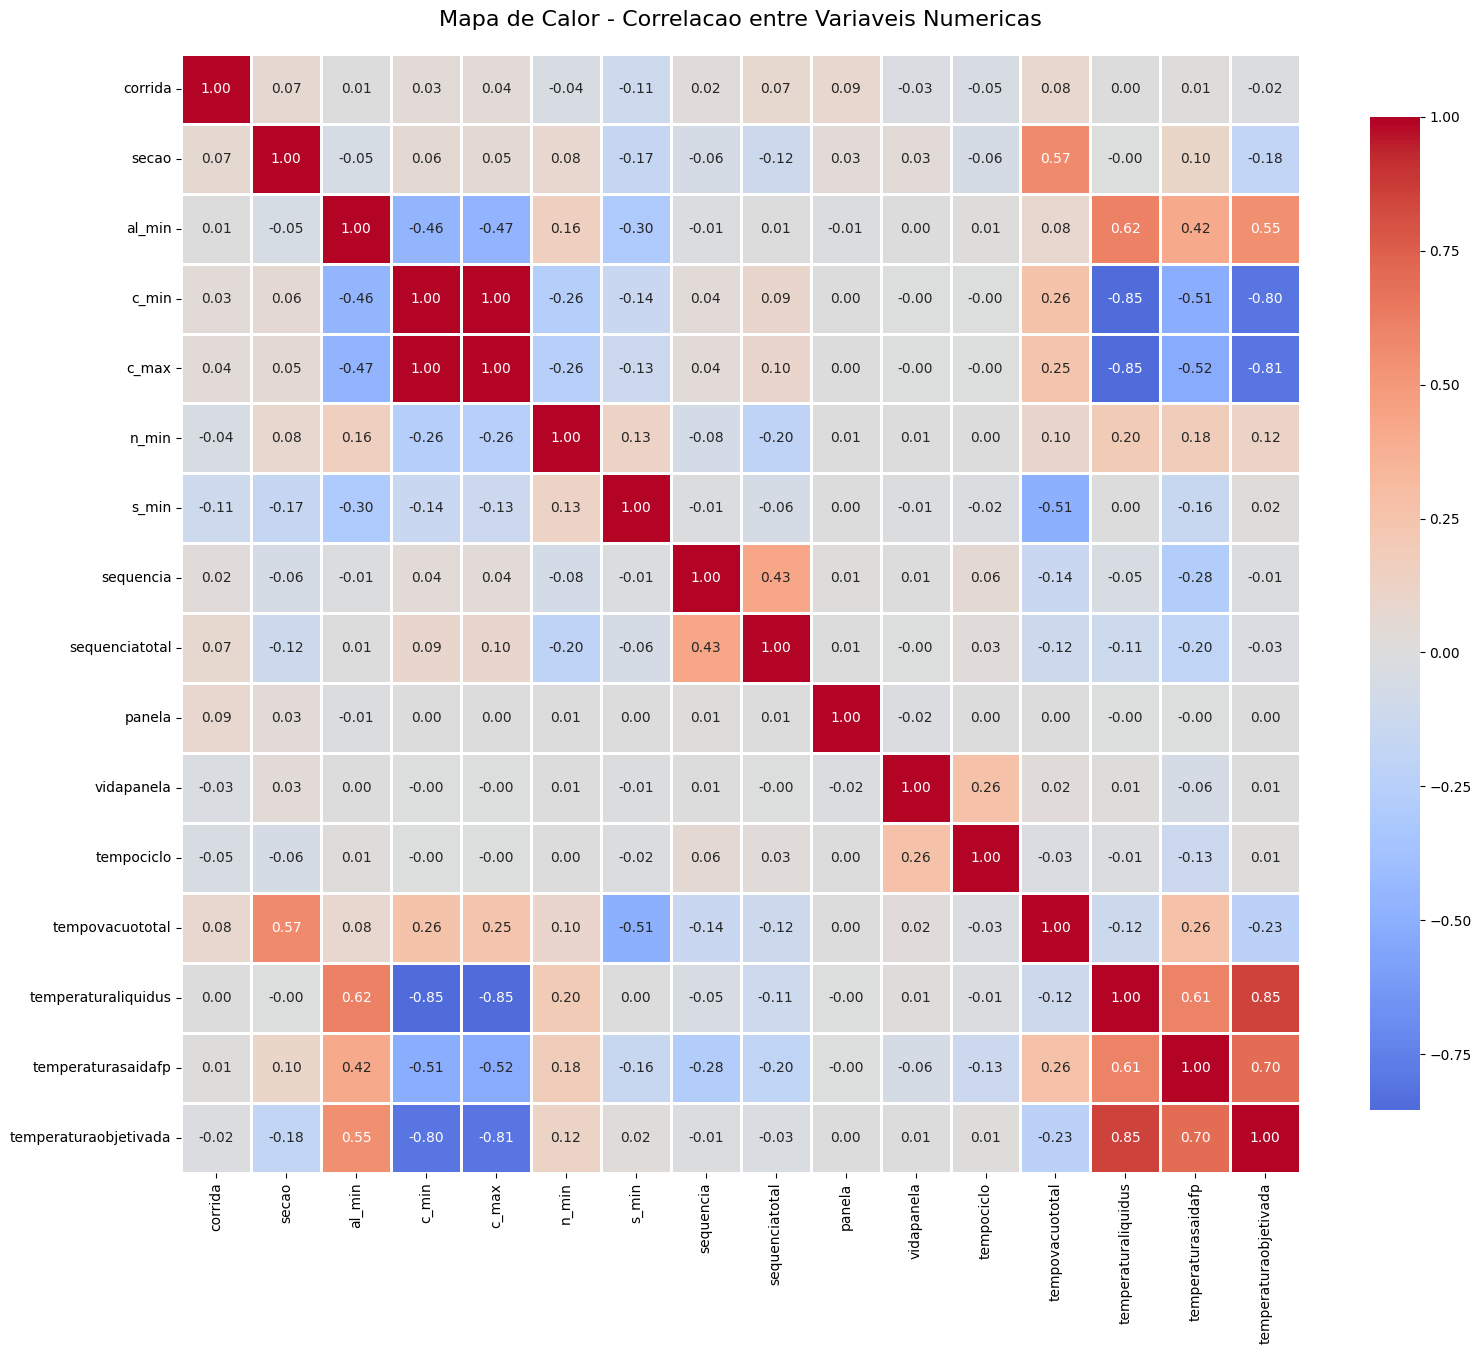

In [26]:
# Criar mapa de calor da correlacao
plt.figure(figsize=(16, 14))
sns.heatmap(correlacao, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Mapa de Calor - Correlacao entre Variaveis Numericas', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### 5.2 Identificacao de Correlacoes Altas

Vamos identificar pares de variaveis com alta correlacao (acima de 0.8 ou abaixo de -0.8) que podem causar multicolinearidade.

In [27]:
# Identificar pares de variaveis com alta correlacao
limite_correlacao = 0.8

# Criar mascara para o triangulo superior (evitar duplicatas)
mascara = np.triu(np.ones_like(correlacao, dtype=bool), k=1)

# Encontrar pares com correlacao alta
pares_alta_correlacao = []
for i in range(len(correlacao.columns)):
    for j in range(i+1, len(correlacao.columns)):
        if abs(correlacao.iloc[i, j]) >= limite_correlacao:
            pares_alta_correlacao.append({
                'Variavel_1': correlacao.columns[i],
                'Variavel_2': correlacao.columns[j],
                'Correlacao': correlacao.iloc[i, j]
            })

if pares_alta_correlacao:
    df_alta_correlacao = pd.DataFrame(pares_alta_correlacao)
    df_alta_correlacao = df_alta_correlacao.sort_values('Correlacao', key=abs, ascending=False)
    print(f"Pares de variaveis com correlacao >= {limite_correlacao} ou <= -{limite_correlacao}:")
    display(df_alta_correlacao)
else:
    print(f"Nao foram encontrados pares de variaveis com correlacao >= {limite_correlacao} ou <= -{limite_correlacao}")

Pares de variaveis com correlacao >= 0.8 ou <= -0.8:


,Variavel_1,Variavel_2,Correlacao
0,c_min,c_max,0.996943
3,c_max,temperaturaliquidus,-0.853762
1,c_min,temperaturaliquidus,-0.853599
5,temperaturaliquidus,temperaturaobjetivada,0.851171
4,c_max,temperaturaobjetivada,-0.809341
2,c_min,temperaturaobjetivada,-0.804098


### 5.3 Mapa de Calor - Apenas Correlacoes Altas

Visualizacao focada apenas nos pares com correlacao significativa.

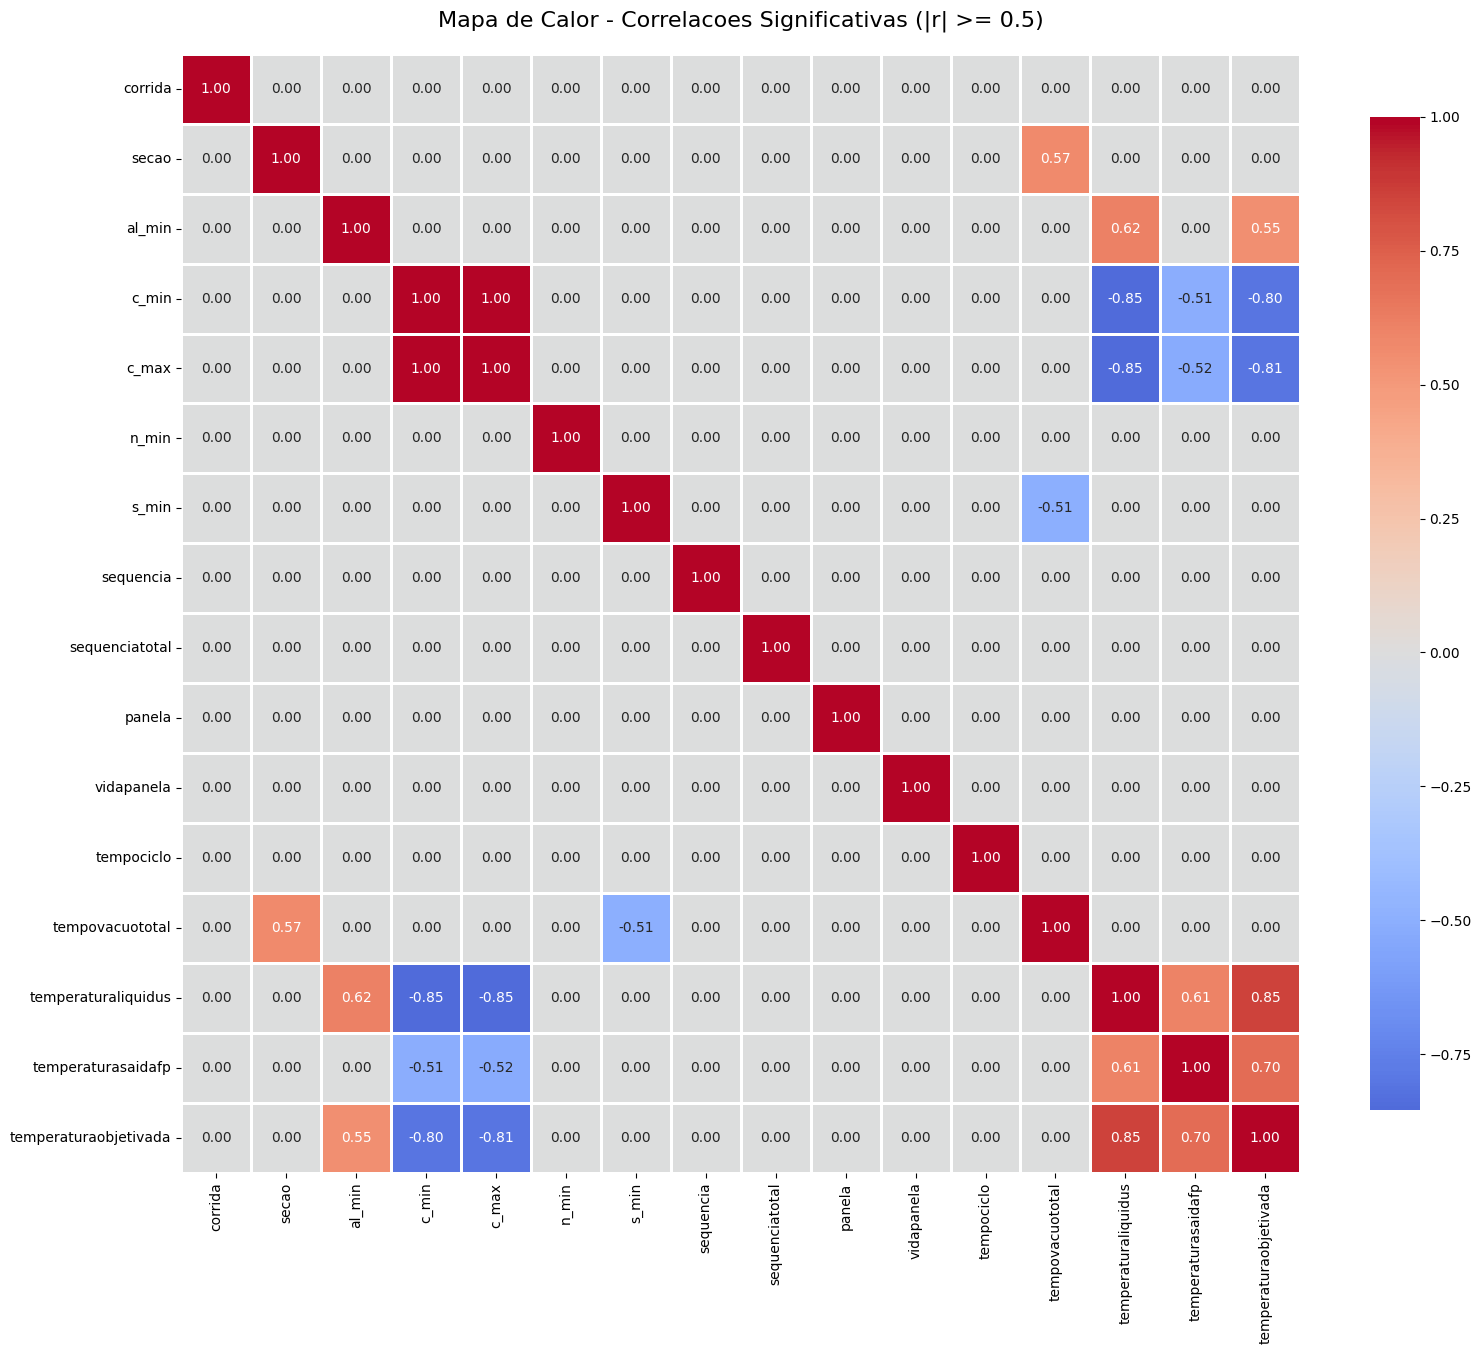

In [28]:
# Criar uma copia da matriz de correlacao e mascarar valores baixos
correlacao_filtrada = correlacao.copy()
mascara_valores = (abs(correlacao_filtrada) < 0.5) & (correlacao_filtrada != 1.0)
correlacao_filtrada[mascara_valores] = 0

plt.figure(figsize=(16, 14))
sns.heatmap(correlacao_filtrada, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Mapa de Calor - Correlacoes Significativas (|r| >= 0.5)', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## 6. Pairplot - Visualizacao de Relacionamentos

Vamos criar pairplots para visualizar os relacionamentos entre as variaveis. Devido ao grande numero de variaveis, vamos dividir em grupos.

In [29]:
# Verificar o numero de variaveis numericas
print(f"Total de variaveis numericas: {len(colunas_numericas)}")

# Dividir as variaveis em grupos para melhor visualizacao
tamanho_grupo = 6
grupos = [colunas_numericas[i:i + tamanho_grupo] for i in range(0, len(colunas_numericas), tamanho_grupo)]

print(f"Numero de grupos para pairplot: {len(grupos)}")
print(f"\nVariaveis em cada grupo:")
for idx, grupo in enumerate(grupos, 1):
    print(f"Grupo {idx}: {grupo}")

Total de variaveis numericas: 16
Numero de grupos para pairplot: 3

Variaveis em cada grupo:
Grupo 1: ['corrida', 'secao', 'al_min', 'c_min', 'c_max', 'n_min']
Grupo 2: ['s_min', 'sequencia', 'sequenciatotal', 'panela', 'vidapanela', 'tempociclo']
Grupo 3: ['tempovacuototal', 'temperaturaliquidus', 'temperaturasaidafp', 'temperaturaobjetivada']



Gerando Pairplot para Grupo 1...


<Figure size 640x480 with 0 Axes>

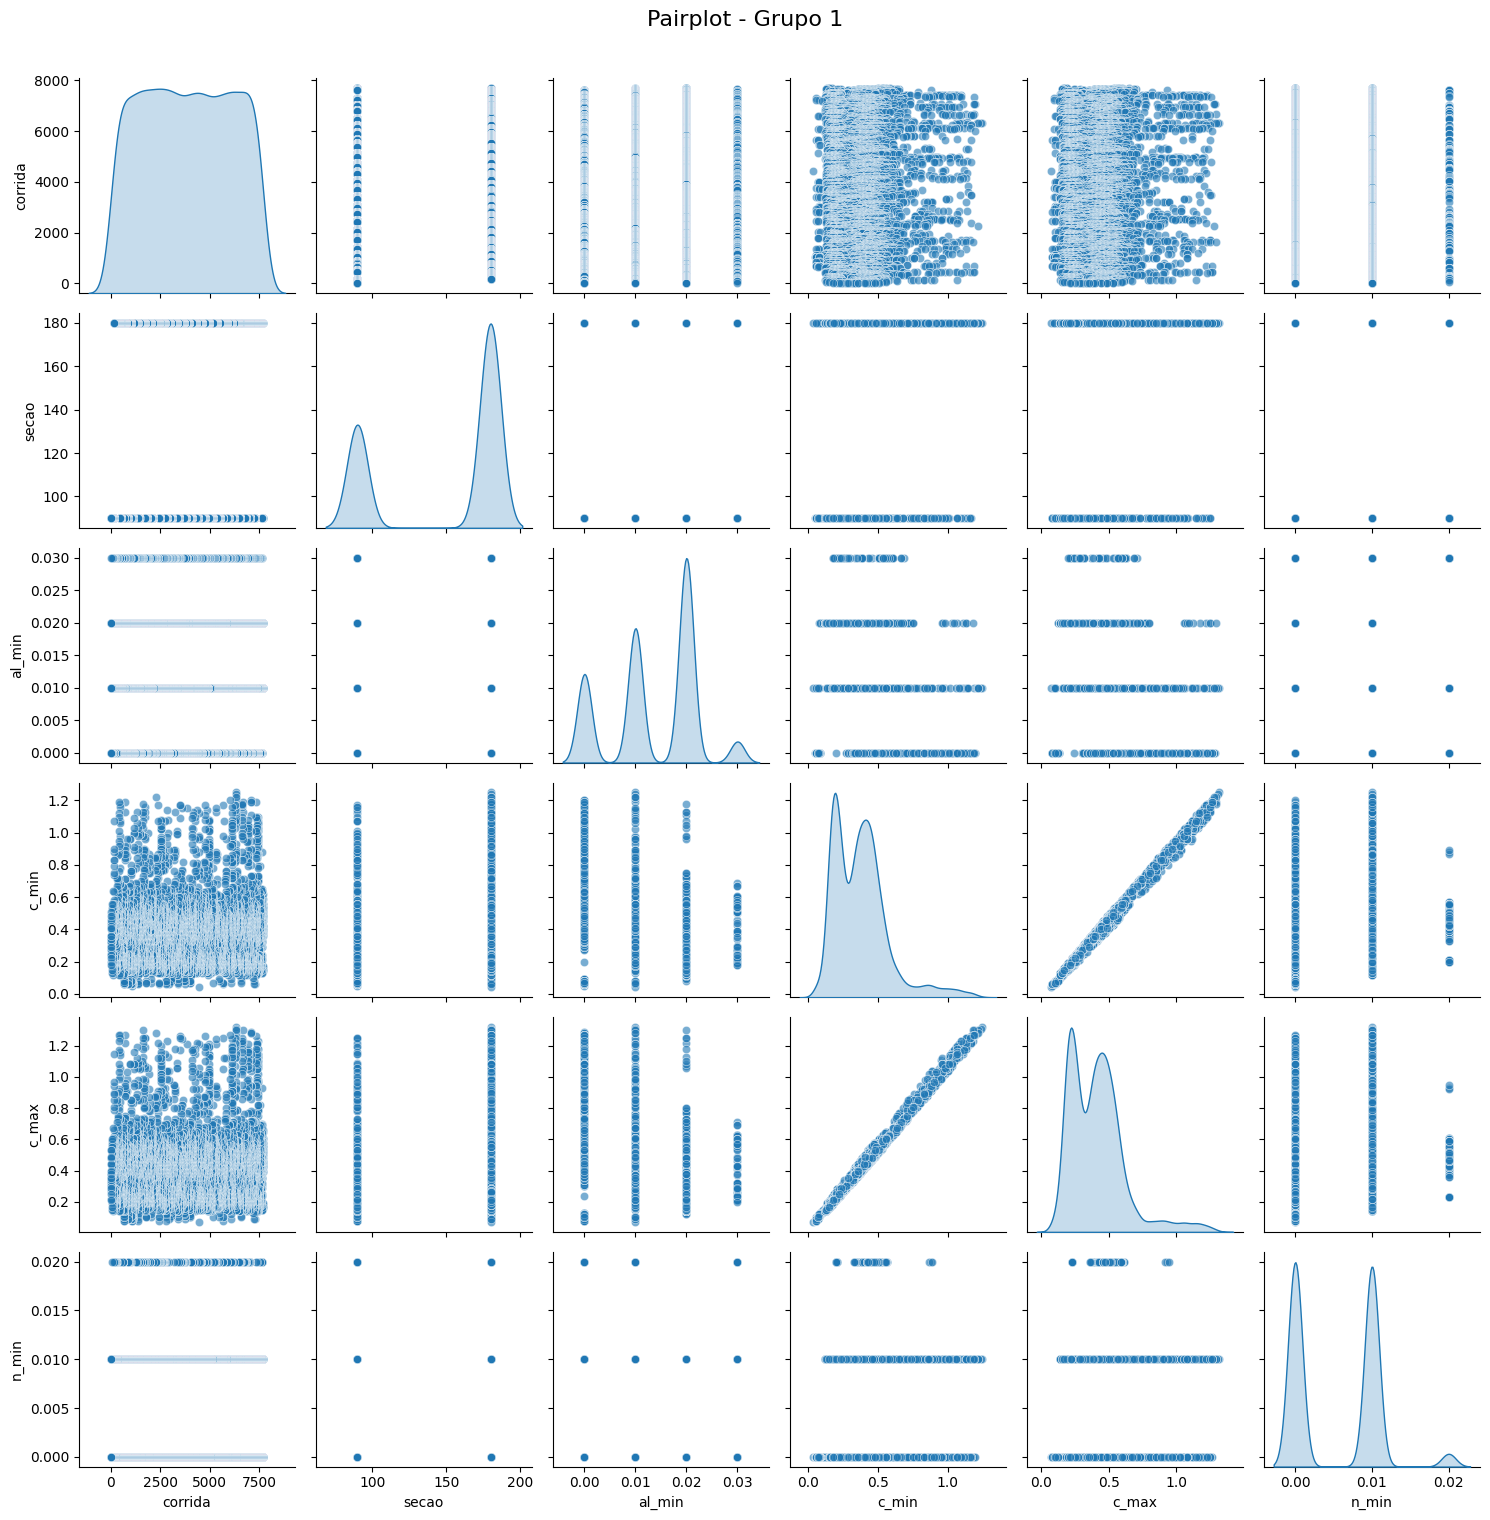


Gerando Pairplot para Grupo 2...


<Figure size 640x480 with 0 Axes>

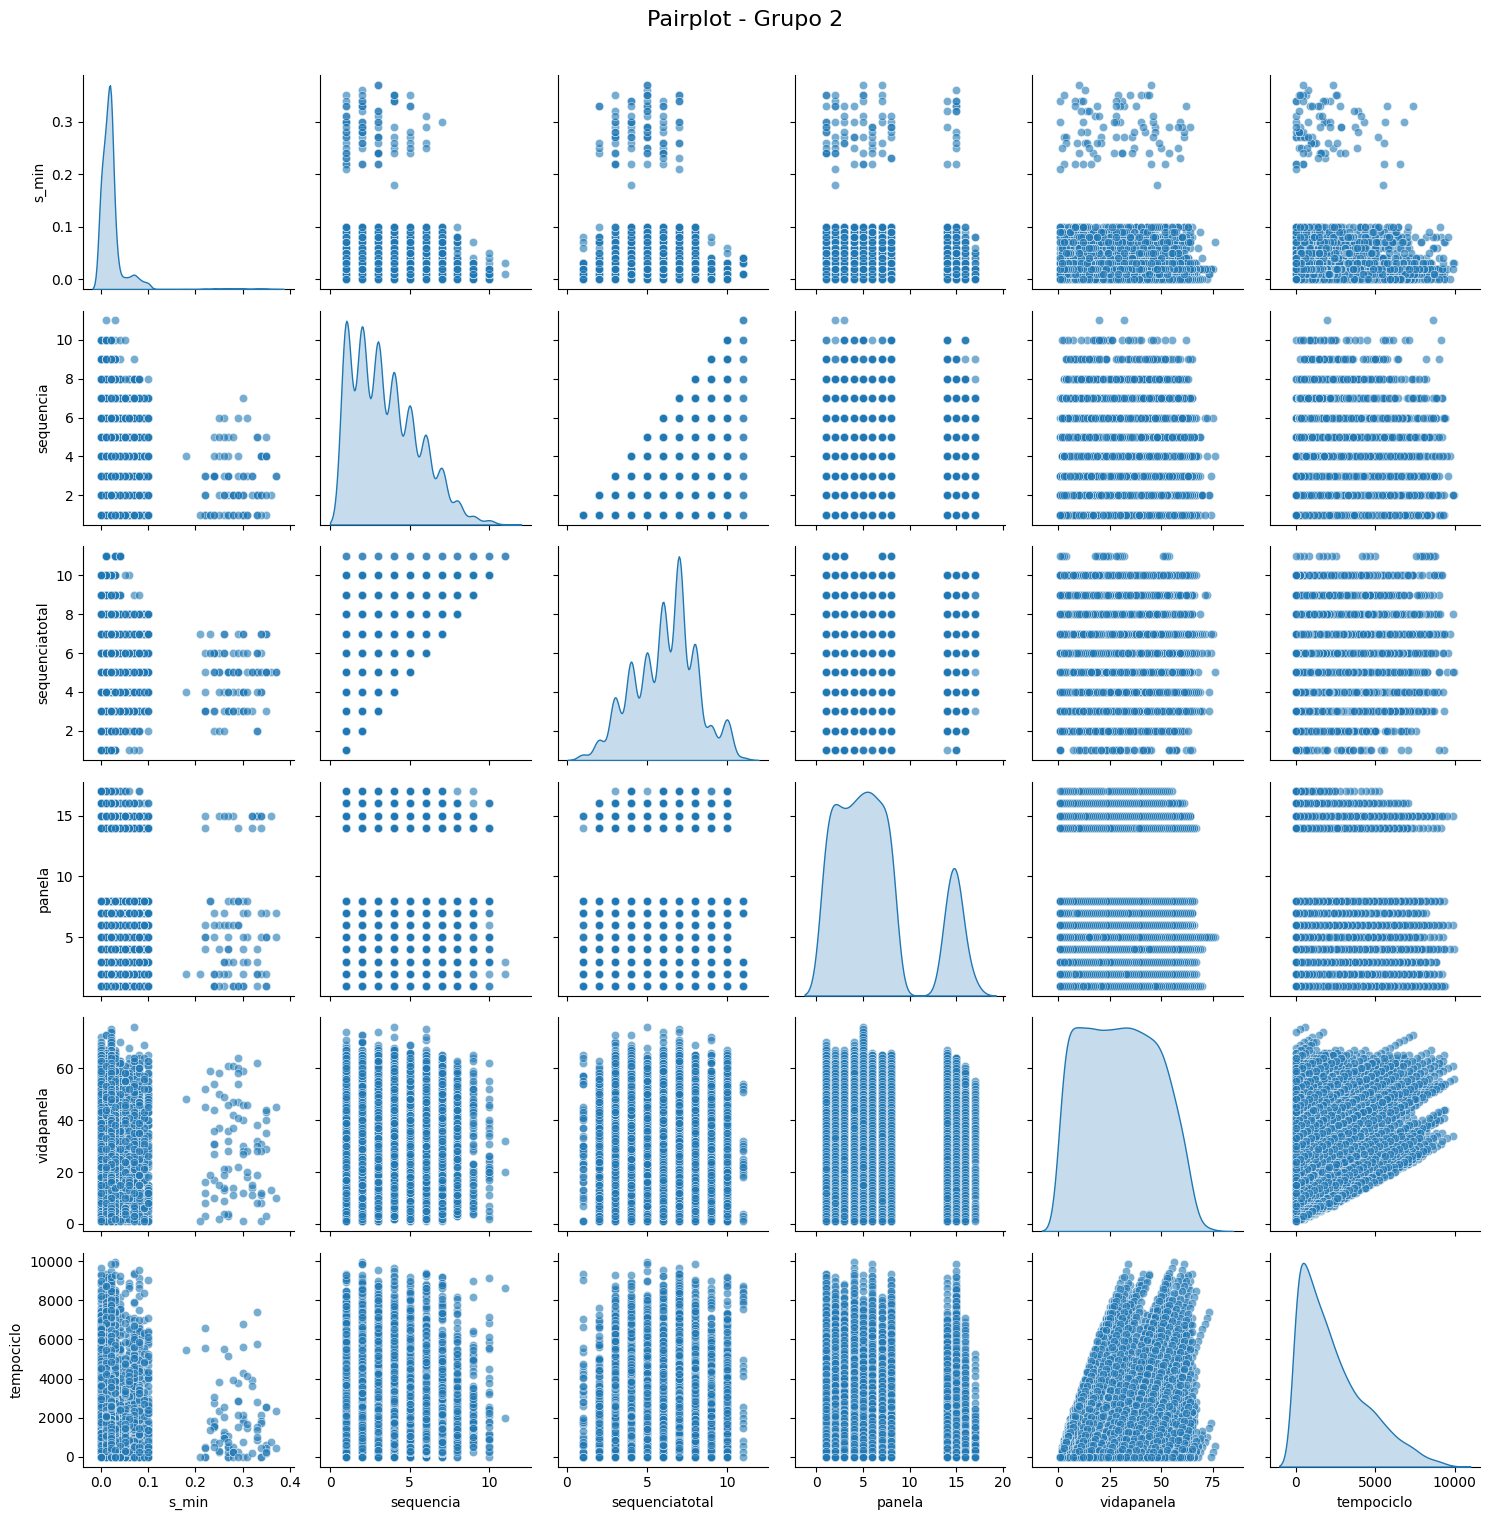


Gerando Pairplot para Grupo 3...


<Figure size 640x480 with 0 Axes>

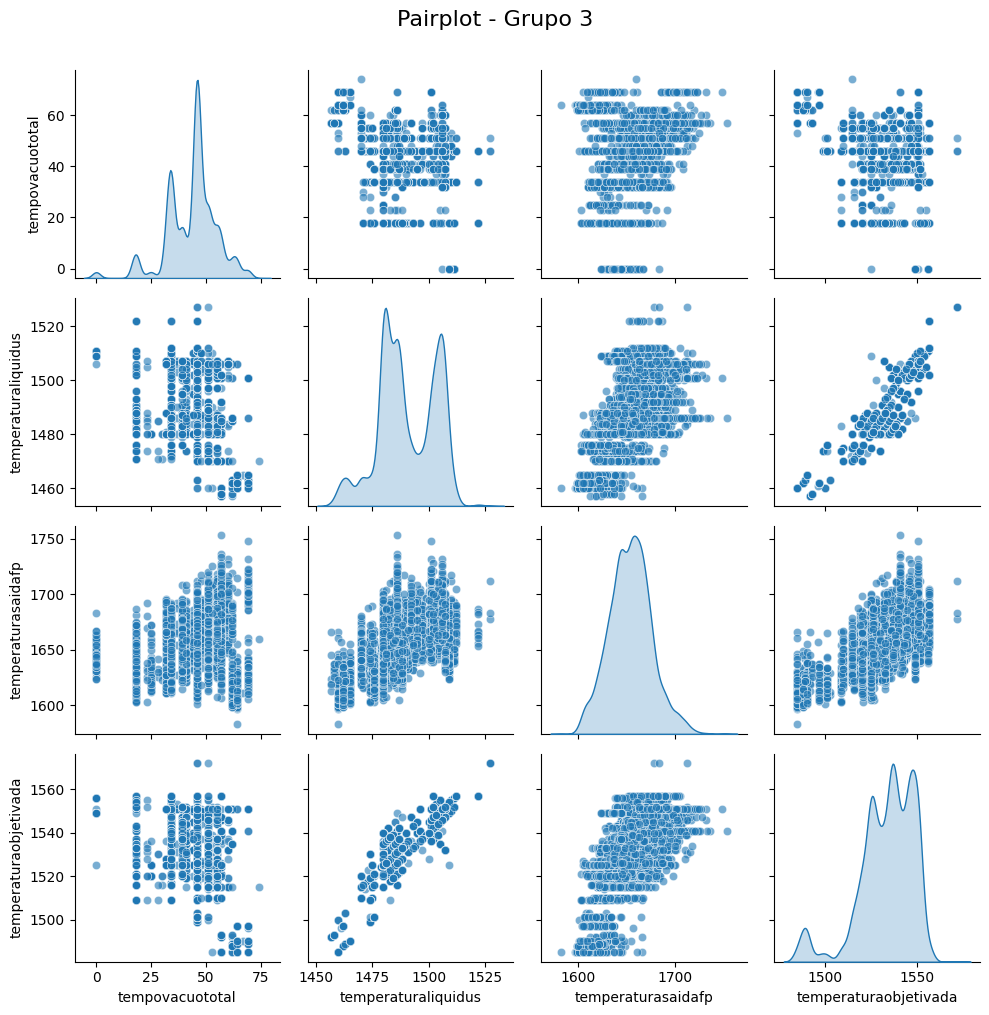

In [30]:
# Criar pairplots para cada grupo
for idx, grupo in enumerate(grupos, 1):
    print(f"\nGerando Pairplot para Grupo {idx}...")
    plt.figure()
    sns.pairplot(data[grupo], diag_kind='kde', plot_kws={'alpha': 0.6})
    plt.suptitle(f'Pairplot - Grupo {idx}', y=1.01, fontsize=16)
    plt.tight_layout()
    plt.show()

## 7. Distribuicao das Variaveis Numericas

Vamos analisar a distribuicao de cada variavel numerica atraves de histogramas.

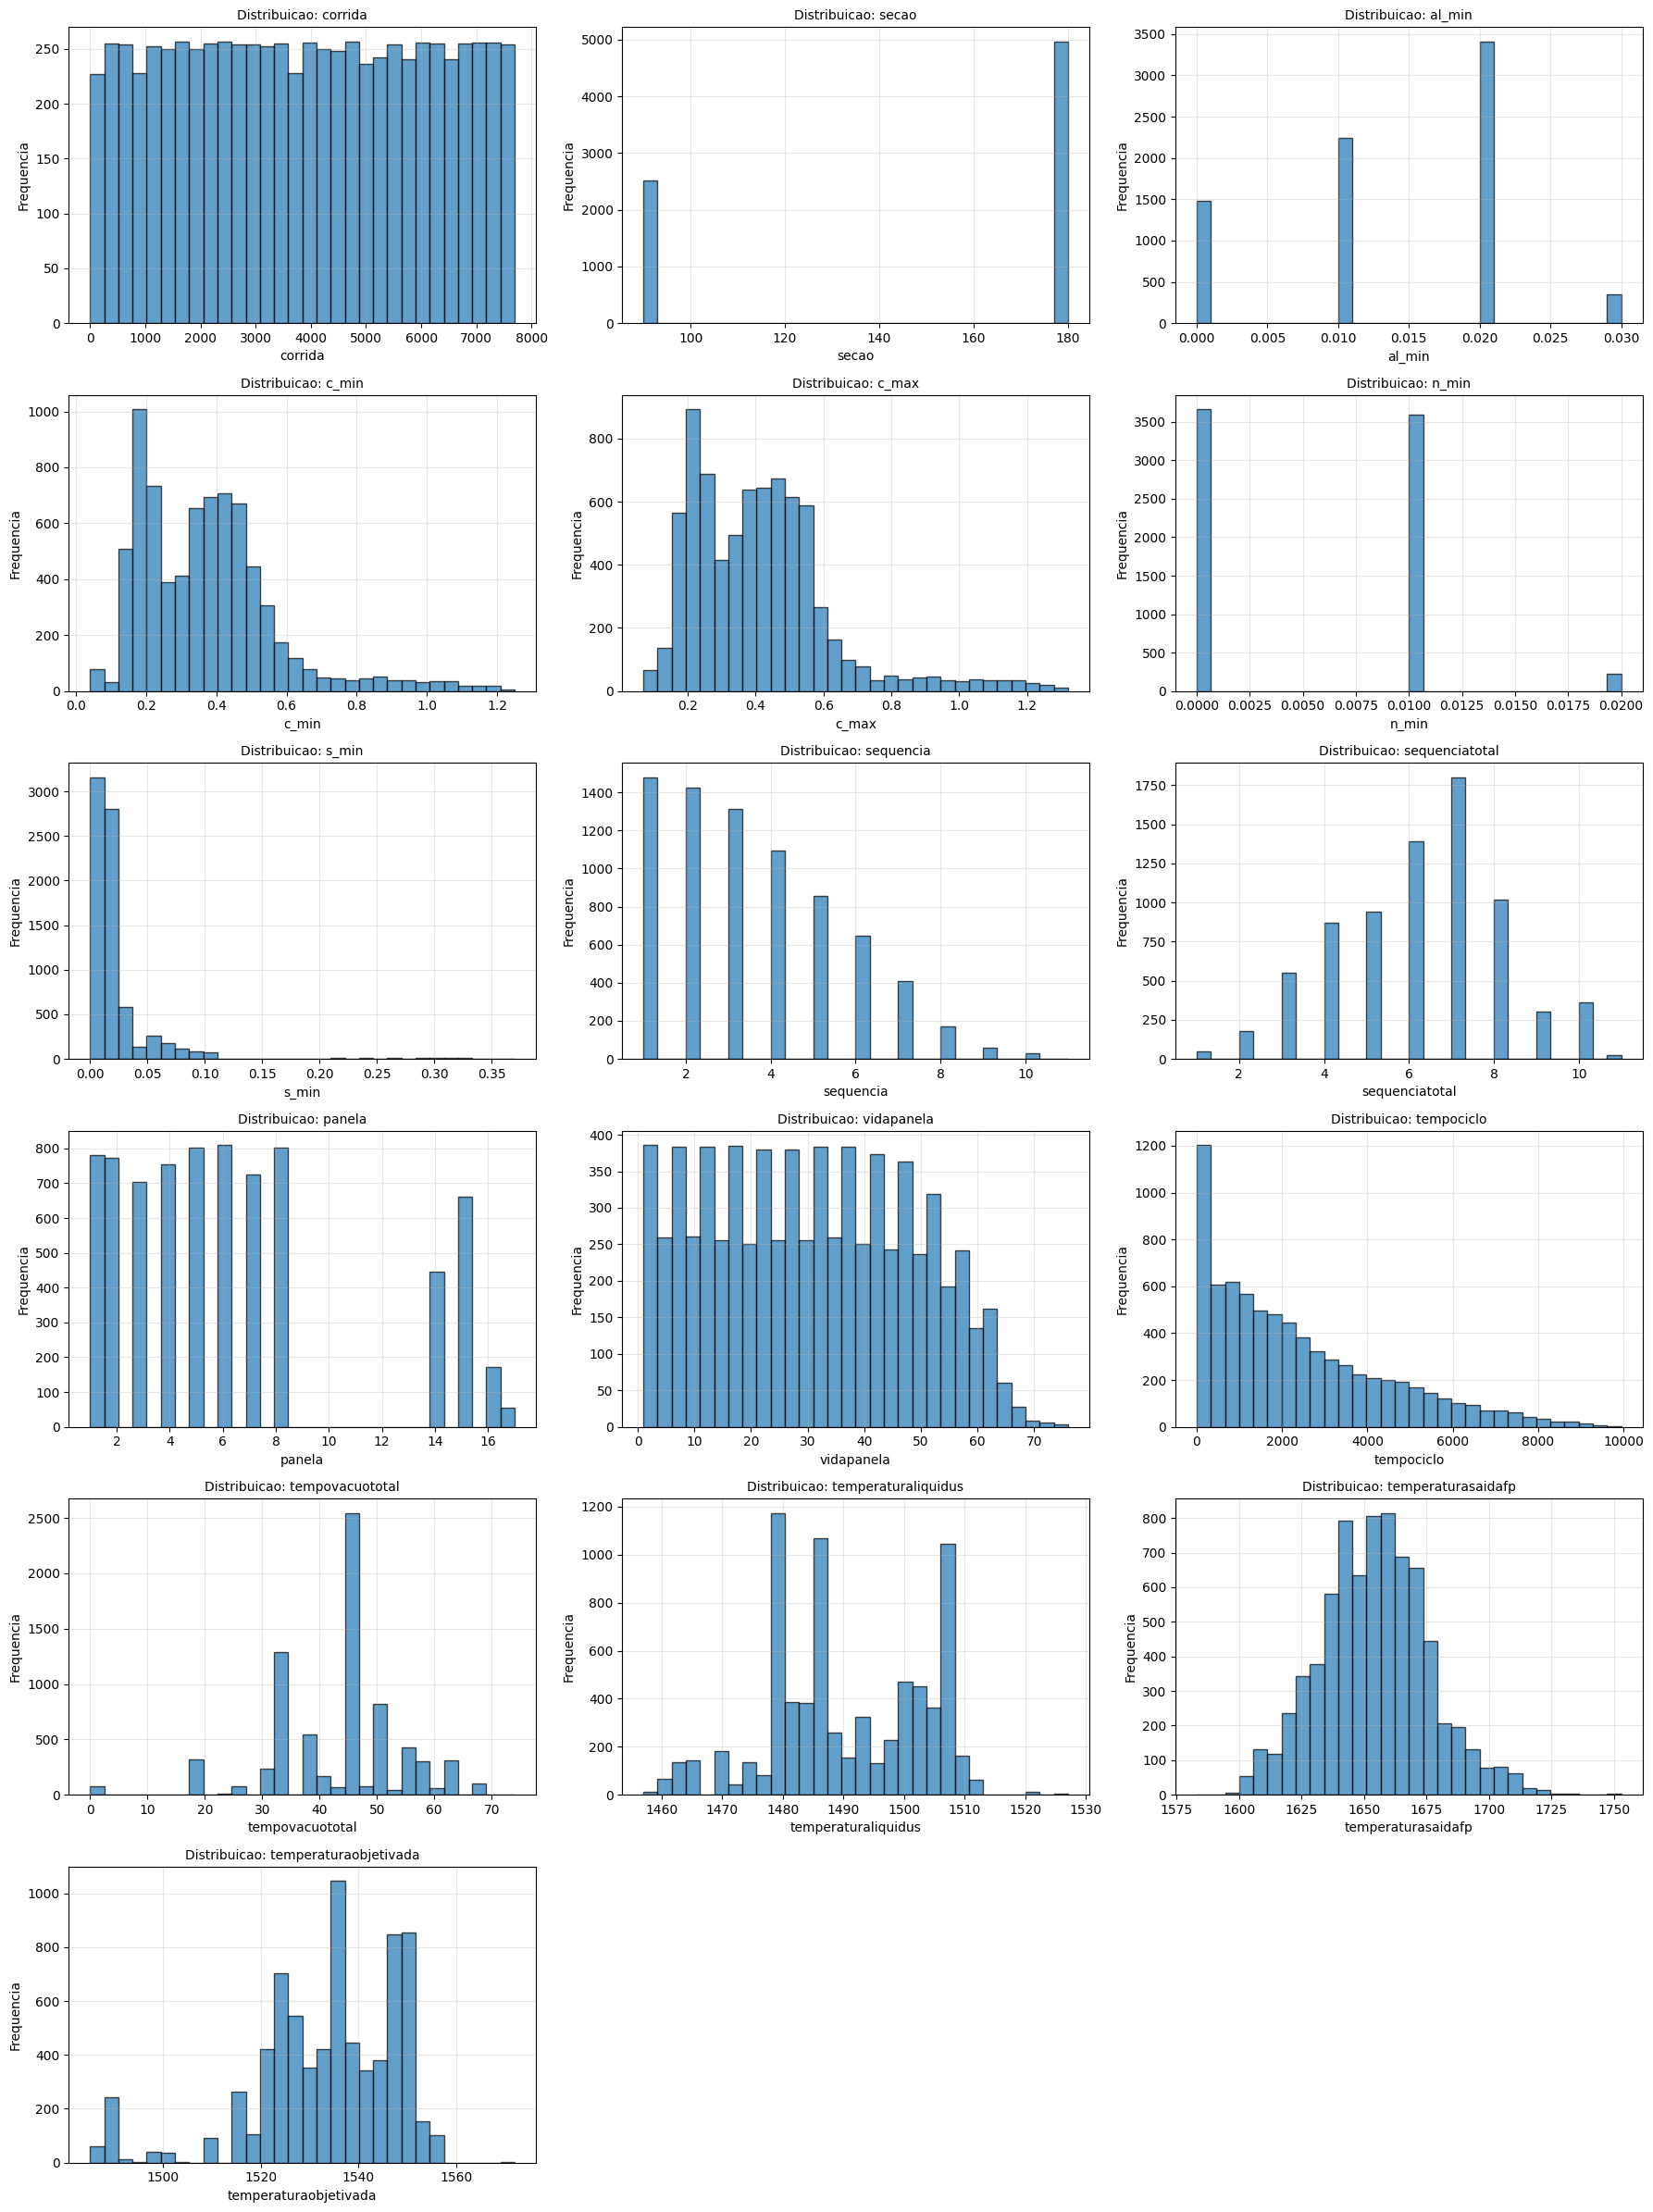

In [31]:
# Criar histogramas para todas as variaveis numericas
num_colunas = 3
num_linhas = int(np.ceil(len(colunas_numericas) / num_colunas))

fig, axes = plt.subplots(num_linhas, num_colunas, figsize=(18, num_linhas * 4))
axes = axes.flatten()

for idx, coluna in enumerate(colunas_numericas):
    axes[idx].hist(data[coluna].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribuicao: {coluna}', fontsize=10)
    axes[idx].set_xlabel(coluna)
    axes[idx].set_ylabel('Frequencia')
    axes[idx].grid(True, alpha=0.3)

# Remover subplots extras
for idx in range(len(colunas_numericas), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 8. Boxplots para Deteccao de Outliers

Vamos criar boxplots para identificar valores atipicos (outliers) nas variaveis numericas.

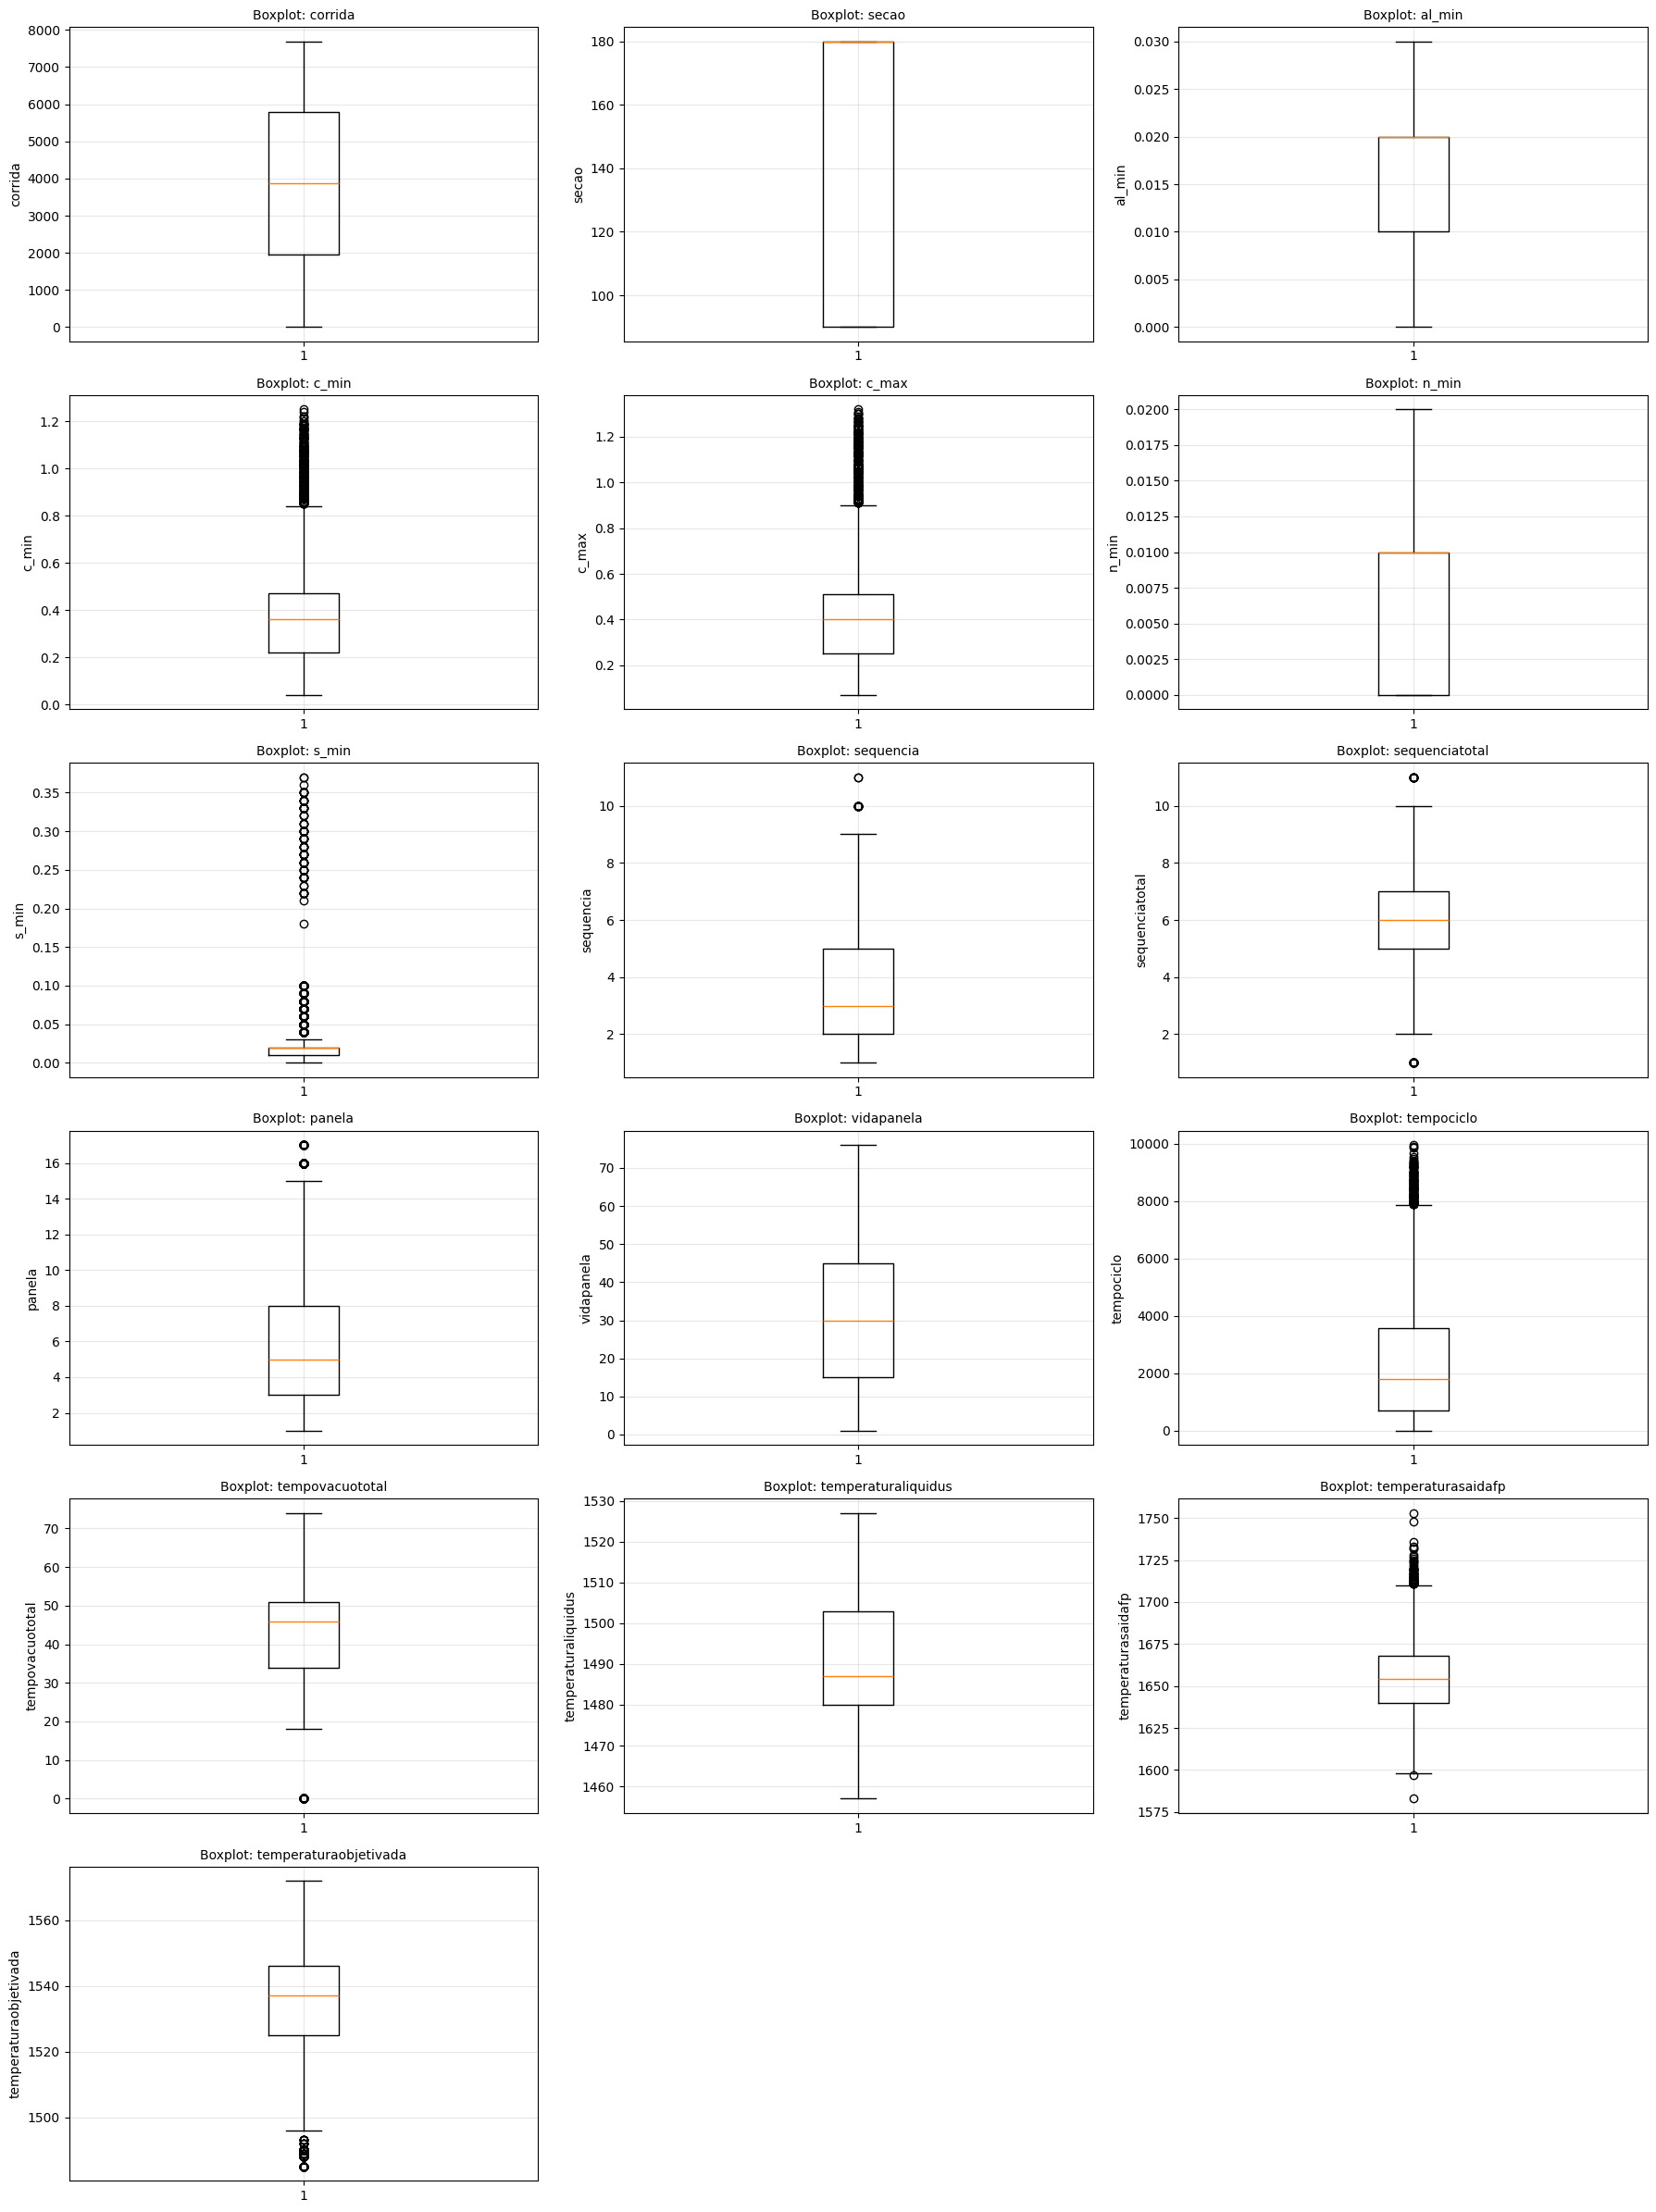

In [32]:
# Criar boxplots para todas as variaveis numericas
fig, axes = plt.subplots(num_linhas, num_colunas, figsize=(18, num_linhas * 4))
axes = axes.flatten()

for idx, coluna in enumerate(colunas_numericas):
    axes[idx].boxplot(data[coluna].dropna(), vert=True)
    axes[idx].set_title(f'Boxplot: {coluna}', fontsize=10)
    axes[idx].set_ylabel(coluna)
    axes[idx].grid(True, alpha=0.3)

# Remover subplots extras
for idx in range(len(colunas_numericas), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 9. Analise de Variaveis Categoricas

Vamos analisar as variaveis categoricas presentes no dataset.

In [33]:
# Identificar variaveis categoricas
colunas_categoricas = data.select_dtypes(include=['object']).columns.tolist()
print(f"Variaveis categoricas identificadas ({len(colunas_categoricas)}):")
print(colunas_categoricas)

# Analisar cada variavel categorica
if len(colunas_categoricas) > 0:
    for coluna in colunas_categoricas:
        print(f"\n{'='*60}")
        print(f"Variavel: {coluna}")
        print(f"{'='*60}")
        print(f"Numero de valores unicos: {data[coluna].nunique()}")
        print(f"\nDistribuicao dos valores:")
        print(data[coluna].value_counts())
        print(f"\nPercentual:")
        print(data[coluna].value_counts(normalize=True) * 100)
else:
    print("\nNao ha variaveis categoricas no dataset.")

Variaveis categoricas identificadas (2):
['acoatual', 'qualidade']

Variavel: acoatual
Numero de valores unicos: 3505

Distribuicao dos valores:
acoatual
17890C45    9
35AA0819    8
A50CB92C    8
6A8459EA    8
920B414C    8
           ..
09839D9E    1
A72AD9BE    1
B79B315C    1
4CE017F0    1
4FD23B68    1
Name: count, Length: 3505, dtype: int64

Percentual:
acoatual
17890C45    0.12024
35AA0819    0.10688
A50CB92C    0.10688
6A8459EA    0.10688
920B414C    0.10688
             ...   
09839D9E    0.01336
A72AD9BE    0.01336
B79B315C    0.01336
4CE017F0    0.01336
4FD23B68    0.01336
Name: proportion, Length: 3505, dtype: float64

Variavel: qualidade
Numero de valores unicos: 253

Distribuicao dos valores:
qualidade
E1B28665    267
56FFE5DC    231
F1291CB0    212
59D14704    207
07025389    200
           ... 
541EC46C      1
138B69A9      1
0FDB4332      1
5A9C08BA      1
7BA7093A      1
Name: count, Length: 253, dtype: int64

Percentual:
qualidade
E1B28665    3.567134
56FFE5DC    3.08

## 10. Analise de Multicolinearidade - VIF (Variance Inflation Factor)

O VIF mede o quanto a variancia de um coeficiente de regressao esta inflada devido a multicolinearidade. Valores de VIF acima de 10 indicam alta multicolinearidade.

In [39]:
# ANALISE DE MULTICOLINEARIDADE - METODO ALTERNATIVO
# Calculo manual do VIF usando regressao linear

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Preparar os dados para calculo do VIF
data_vif = data[colunas_numericas].dropna()

# Funcao para calcular VIF manualmente
def calcular_vif_manual(X, feature_idx):
    """
    Calcula VIF para uma feature especifica
    VIF = 1 / (1 - R²)
    """
    # Separar a feature target das outras
    y = X[:, feature_idx]
    X_sem_feature = np.delete(X, feature_idx, axis=1)
    
    # Treinar modelo de regressao
    model = LinearRegression()
    model.fit(X_sem_feature, y)
    
    # Calcular R²
    y_pred = model.predict(X_sem_feature)
    r2 = r2_score(y, y_pred)
    
    # Calcular VIF
    vif = 1 / (1 - r2) if r2 < 0.9999 else np.inf
    
    return vif

# Calcular VIF para cada variavel
print("Calculando VIF para cada variavel...")
vif_valores = []

for i, coluna in enumerate(colunas_numericas):
    vif = calcular_vif_manual(data_vif.values, i)
    vif_valores.append(vif)
    print(f"  {coluna}: VIF = {vif:.2f}")

# Criar DataFrame com resultados
vif_data = pd.DataFrame({
    'Variavel': colunas_numericas,
    'VIF': vif_valores
})

# Ordenar por VIF
vif_data = vif_data.sort_values('VIF', ascending=False)

print("\n" + "="*60)
print("Variance Inflation Factor (VIF) para cada variavel:")
print("="*60)
display(vif_data)

print("\n" + "="*60)
print("Interpretacao do VIF:")
print("VIF = 1: Nao ha correlacao com outras variaveis")
print("1 < VIF < 5: Correlacao moderada")
print("5 < VIF < 10: Correlacao alta")
print("VIF > 10: Multicolinearidade muito alta (considerar remocao)")
print("="*60)

Calculando VIF para cada variavel...
  corrida: VIF = 1.04
  secao: VIF = 1.74
  al_min: VIF = 2.04
  c_min: VIF = 180.28
  c_max: VIF = 178.44
  n_min: VIF = 1.23
  s_min: VIF = 1.69
  sequencia: VIF = 1.39
  sequenciatotal: VIF = 1.34
  panela: VIF = 1.01
  vidapanela: VIF = 1.09
  tempociclo: VIF = 1.13
  tempovacuototal: VIF = 3.05
  temperaturaliquidus: VIF = 6.62
  temperaturasaidafp: VIF = 3.99
  temperaturaobjetivada: VIF = 8.12

Variance Inflation Factor (VIF) para cada variavel:


,Variavel,VIF
3,c_min,180.278930
4,c_max,178.435470
15,temperaturaobjetivada,8.122349
13,temperaturaliquidus,6.621292
14,temperaturasaidafp,3.993027
12,tempovacuototal,3.053155
2,al_min,2.040418
1,secao,1.740872
6,s_min,1.686371
7,sequencia,1.393434



Interpretacao do VIF:
VIF = 1: Nao ha correlacao com outras variaveis
1 < VIF < 5: Correlacao moderada
5 < VIF < 10: Correlacao alta
VIF > 10: Multicolinearidade muito alta (considerar remocao)


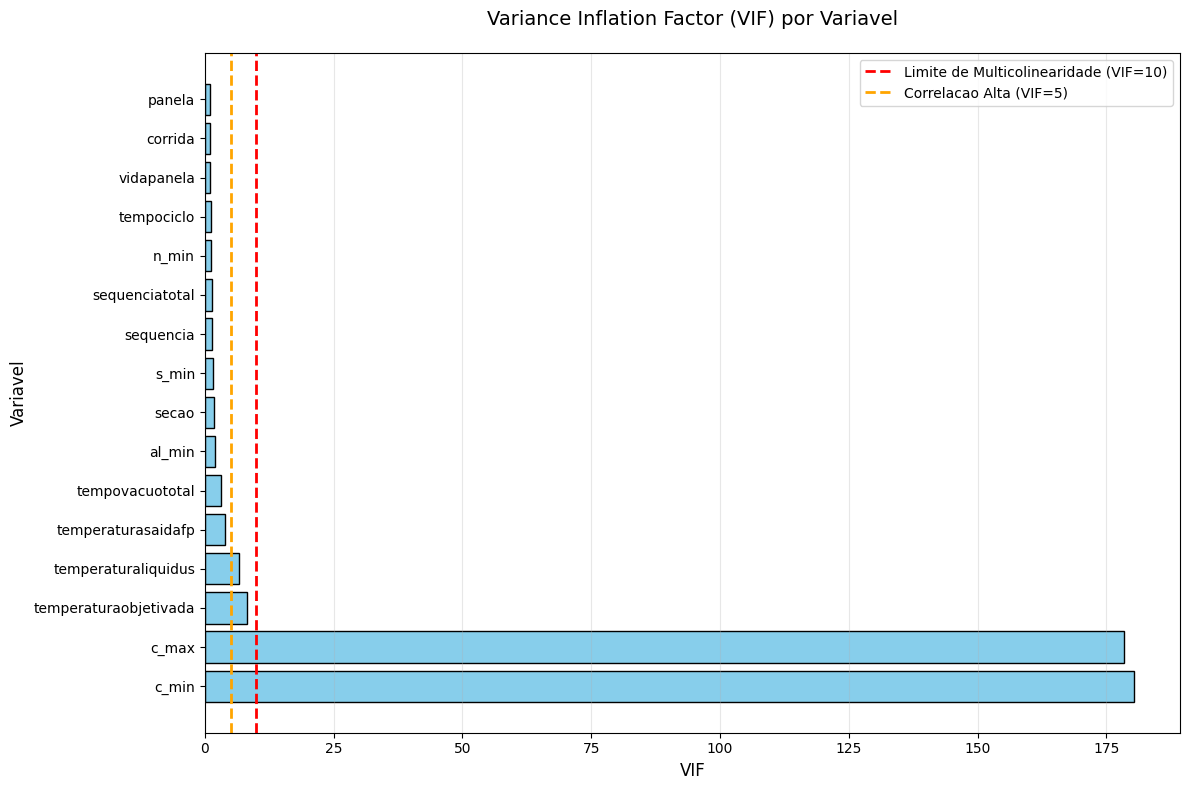

In [40]:
# Visualizar VIF
plt.figure(figsize=(12, 8))
plt.barh(vif_data["Variavel"], vif_data["VIF"], color='skyblue', edgecolor='black')
plt.axvline(x=10, color='red', linestyle='--', linewidth=2, label='Limite de Multicolinearidade (VIF=10)')
plt.axvline(x=5, color='orange', linestyle='--', linewidth=2, label='Correlacao Alta (VIF=5)')
plt.xlabel('VIF', fontsize=12)
plt.ylabel('Variavel', fontsize=12)
plt.title('Variance Inflation Factor (VIF) por Variavel', fontsize=14, pad=20)
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 11. Recomendacoes de Variaveis para Remocao

Com base na analise de correlacao e VIF, vamos identificar as variaveis que apresentam alta multicolinearidade.

In [41]:
# Identificar variaveis com VIF alto (> 10)
variaveis_vif_alto = vif_data[vif_data['VIF'] > 10]

print("RECOMENDACOES PARA REMOCAO DE VARIAVEIS")
print("="*80)
print("\n1. VARIAVEIS COM VIF > 10 (MULTICOLINEARIDADE MUITO ALTA):")
print("-"*80)
if len(variaveis_vif_alto) > 0:
    for idx, row in variaveis_vif_alto.iterrows():
        print(f"   - {row['Variavel']}: VIF = {row['VIF']:.2f}")
    print("\n   RECOMENDACAO: Considere remover estas variaveis, pois apresentam alta")
    print("   multicolinearidade e podem prejudicar o desempenho do modelo.")
else:
    print("   Nenhuma variavel com VIF > 10 identificada.")

print("\n2. PARES DE VARIAVEIS COM CORRELACAO MUITO ALTA (|r| >= 0.8):")
print("-"*80)
if pares_alta_correlacao:
    for par in pares_alta_correlacao:
        print(f"   - {par['Variavel_1']} <-> {par['Variavel_2']}: r = {par['Correlacao']:.3f}")
    print("\n   RECOMENDACAO: Para cada par, considere manter apenas uma das variaveis.")
    print("   Escolha a variavel que tem maior relevancia para o problema ou maior")
    print("   correlacao com a variavel target.")
else:
    print("   Nenhum par de variaveis com correlacao >= 0.8 identificado.")

print("\n3. VARIAVEIS JA REMOVIDAS:")
print("-"*80)
for col in colunas_existentes:
    print(f"   - {col}")

print("\n" + "="*80)

RECOMENDACOES PARA REMOCAO DE VARIAVEIS

1. VARIAVEIS COM VIF > 10 (MULTICOLINEARIDADE MUITO ALTA):
--------------------------------------------------------------------------------
   - c_min: VIF = 180.28
   - c_max: VIF = 178.44

   RECOMENDACAO: Considere remover estas variaveis, pois apresentam alta
   multicolinearidade e podem prejudicar o desempenho do modelo.

2. PARES DE VARIAVEIS COM CORRELACAO MUITO ALTA (|r| >= 0.8):
--------------------------------------------------------------------------------
   - c_min <-> c_max: r = 0.997
   - c_min <-> temperaturaliquidus: r = -0.854
   - c_min <-> temperaturaobjetivada: r = -0.804
   - c_max <-> temperaturaliquidus: r = -0.854
   - c_max <-> temperaturaobjetivada: r = -0.809
   - temperaturaliquidus <-> temperaturaobjetivada: r = 0.851

   RECOMENDACAO: Para cada par, considere manter apenas uma das variaveis.
   Escolha a variavel que tem maior relevancia para o problema ou maior
   correlacao com a variavel target.

3. VARIAVEIS J

## 12. Resumo Final da Analise Exploratoria

In [42]:
print("RESUMO DA ANALISE EXPLORATORIA DE DADOS")
print("="*80)

print(f"\n1. DIMENSOES DO DATASET:")
print(f"   - Numero de registros: {data.shape[0]}")
print(f"   - Numero de variaveis: {data.shape[1]}")

print(f"\n2. TIPOS DE VARIAVEIS:")
print(f"   - Variaveis numericas: {len(colunas_numericas)}")
print(f"   - Variaveis categoricas: {len(colunas_categoricas)}")

print(f"\n3. QUALIDADE DOS DADOS:")
valores_faltantes_total = data.isnull().sum().sum()
print(f"   - Total de valores faltantes: {valores_faltantes_total}")
print(f"   - Percentual de dados completos: {((data.size - valores_faltantes_total) / data.size * 100):.2f}%")

print(f"\n4. MULTICOLINEARIDADE:")
num_vif_alto = len(variaveis_vif_alto)
print(f"   - Variaveis com VIF > 10: {num_vif_alto}")
print(f"   - Pares com correlacao >= 0.8: {len(pares_alta_correlacao)}")

print(f"\n5. VARIAVEIS REMOVIDAS:")
print(f"   - Total de variaveis removidas: {len(colunas_existentes)}")

print("\n" + "="*80)
print("PROXIMOS PASSOS:")
print("1. Considerar a remocao de variaveis com VIF muito alto")
print("2. Analisar e tratar outliers se necessario")
print("3. Verificar a necessidade de normalizacao/padronizacao das variaveis")
print("4. Avaliar a necessidade de engenharia de features")
print("5. Preparar os dados para o treinamento do modelo")
print("="*80)

RESUMO DA ANALISE EXPLORATORIA DE DADOS

1. DIMENSOES DO DATASET:
   - Numero de registros: 7485
   - Numero de variaveis: 18

2. TIPOS DE VARIAVEIS:
   - Variaveis numericas: 16
   - Variaveis categoricas: 2

3. QUALIDADE DOS DADOS:
   - Total de valores faltantes: 0
   - Percentual de dados completos: 100.00%

4. MULTICOLINEARIDADE:
   - Variaveis com VIF > 10: 2
   - Pares com correlacao >= 0.8: 6

5. VARIAVEIS REMOVIDAS:
   - Total de variaveis removidas: 4

PROXIMOS PASSOS:
1. Considerar a remocao de variaveis com VIF muito alto
2. Analisar e tratar outliers se necessario
3. Verificar a necessidade de normalizacao/padronizacao das variaveis
4. Avaliar a necessidade de engenharia de features
5. Preparar os dados para o treinamento do modelo
